# House Price Pridiction Model

## Importing Dependencies for the project

In [24]:
# importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

## Importing dataset

In [ ]:
path = "housing_price.csv"
df = pd.read_csv(path)

In [3]:
# print first 5 rows of the dataset
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.shape

(20640, 10)

In [5]:
# Print the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
# Print some basic statistics for numerical features only
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Handling missing values

In [7]:
# checking the missing values
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [8]:
# total_bedroom feature has 207 missing values
# lets replace the missing values with the median of the feature
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True) # inplance = True is for reflect the change the original dataset

In [9]:
# check again for missing values
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


##  Exploratory Data Analysis

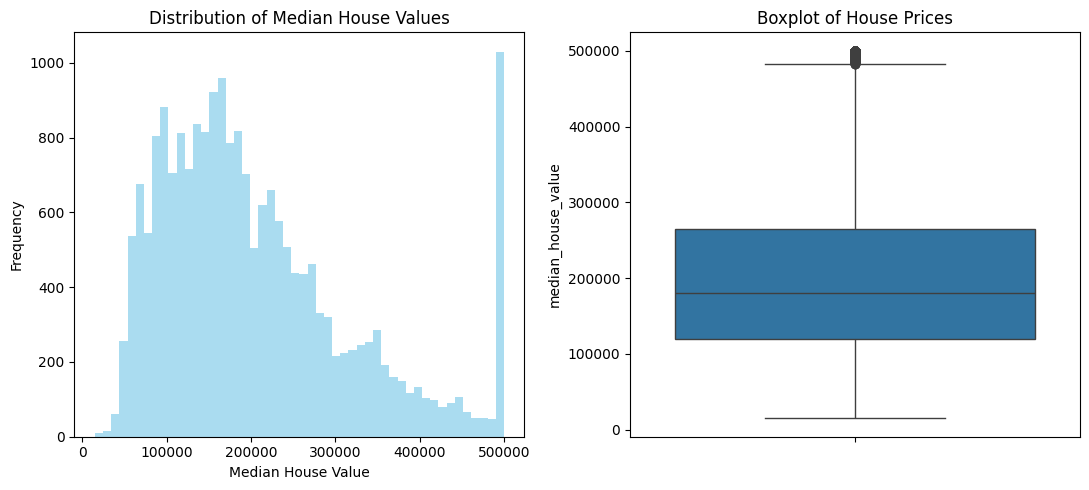

In [10]:
plt.figure(figsize=(11,5)) # plt.figure() creates a new figure (a blank canvas) for the plots.

# The figsize=(11, 5) argument sets the width and height of the figure in inches — here, 11 inches wide and 5 inches tall.

plt.subplot(1,2,1) #  plt.subplot(nrows, ncols, index) divides the figure into a grid of subplots.

# 1 row 2 columns & 1st subplot on the left side.

plt.hist(df['median_house_value'], bins=50, alpha = 0.7, color='skyblue')

# plt.hist() creates a histogram, which shows how often values occur within certain ranges (bins).
# df['median_house_value'] — this is the column from your DataFrame containing house prices.
# bins=50 — divides the data into 50 equal-width intervals (more bins = more detail).
# alpha=0.7 — controls transparency (1.0 = opaque, 0 = invisible).
# color='skyblue' — sets the bar color to a light blue shade.

plt.xlabel('Median House Value') # X-axis → represents house prices .
plt.ylabel('Frequency') # Y-axis → represents how frequently those prices appear in the dataset
plt.title('Distribution of Median House Values') # Adds the title “Distribution of House Prices” above the first subplot.

plt.subplot(1, 2, 2) # Moves to the second subplot (right side) in the 1×2 grid.

sns.boxplot(y=df['median_house_value']) # Uses Seaborn’s boxplot() function to create a boxplot of house prices.

# y=df['median_house_value'] means the boxplot will be vertical (showing distribution along the Y-axis).

plt.title('Boxplot of House Prices') # add title of the second subplot

plt.tight_layout() # Automatically adjusts spacing between the two subplots to prevent overlap of titles, labels, or axes.

plt.show() # Display the plots.

In [11]:
# removing outliers in the feature of df['median_house_value']

Q1 = df['median_house_value'].quantile(0.25)
Q3 = df['median_house_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['median_house_value'] >= lower_bound) & (df['median_house_value'] <= upper_bound)].copy()

## Feature Engineering

In [12]:
# Create new feature which are more meaning full

df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

In [13]:
df.shape

(19569, 13)

In [14]:
# Handle categorical variable (ocean_proximity)
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [15]:
le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

In [16]:
# Prepare features and target

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

## Train Test Split

In [17]:
# Dividing the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# check the shape of both test and train data split
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(15655, 12)
(3914, 12)
(15655,)
(3914,)


## Feature Scaling

In [19]:
# Scale the independent features on common Scale using StandardScaler Function
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# check the scaled values for both X_train_scaled & X_test_scaled

print(X_test_scaled.std())
print(X_train_scaled.std())

0.9684103274795146
1.0


## Train & Evaluate the models

In [21]:
# creating the directory for models
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(),
    'Ridge Regression': Ridge(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}

In [22]:
# Train the models
for name, model in models.items():
  if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
    model.fit(X_train_scaled, y_train)
    y_perd = model.predict(X_test_scaled)
  else:
    model.fit(X_train, y_train)
    y_perd = model.predict(X_test)



In [29]:
# Evaluate the models

mse = mean_squared_error(y_test, y_perd)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_perd)
r2 = r2_score(y_test, y_perd)

In [30]:
# cross validation
result = {}
for name, model in models.items():
  if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
  else:
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

  result[name] = {
      'MSE': mse,
      'RMSE': rmse,
      'MAE': mae,
      'R2 Score': r2,
      'CV Score': cv_scores.mean(),
      'CV Score Std': cv_scores.std()
  }

  print(f"Model: {name} Results: ")
  print(f"MSE: {mse:.2f}")
  print(f"RMSE: {rmse:.2f}")
  print(f"MAE: {mae:.2f}")
  print(f"R2 Score: {r2:.4f}")
  print(f"CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Model: Linear Regression Results: 
MSE: 2164407124.30
RMSE: 46523.19
MAE: 32977.79
R2 Score: 0.7660
CV Score: 0.5995 (+/- 0.0126)
Model: Lasso Regression Results: 
MSE: 2164407124.30
RMSE: 46523.19
MAE: 32977.79
R2 Score: 0.7660
CV Score: 0.5995 (+/- 0.0126)
Model: Ridge Regression Results: 
MSE: 2164407124.30
RMSE: 46523.19
MAE: 32977.79
R2 Score: 0.7660
CV Score: 0.5995 (+/- 0.0126)
Model: Decision Tree Results: 
MSE: 2164407124.30
RMSE: 46523.19
MAE: 32977.79
R2 Score: 0.7660
CV Score: 0.5416 (+/- 0.0138)
Model: Random Forest Results: 
MSE: 2164407124.30
RMSE: 46523.19
MAE: 32977.79
R2 Score: 0.7660
CV Score: 0.7744 (+/- 0.0064)
Model: Gradient Boosting Results: 
MSE: 2164407124.30
RMSE: 46523.19
MAE: 32977.79
R2 Score: 0.7660
CV Score: 0.7455 (+/- 0.0086)


In [32]:
# Comparing the Models Performance
results_df = pd.DataFrame(result).T
results_df = results_df.sort_values(by='R2 Score', ascending=False)
results_df

,MSE,RMSE,MAE,R2 Score,CV Score,CV Score Std
Linear Regression,2.164407e+09,46523.189103,32977.786115,0.765965,0.599519,0.012566
Lasso Regression,2.164407e+09,46523.189103,32977.786115,0.765965,0.599528,0.012557
Ridge Regression,2.164407e+09,46523.189103,32977.786115,0.765965,0.599531,0.012557
Decision Tree,2.164407e+09,46523.189103,32977.786115,0.765965,0.541590,0.013787
Random Forest,2.164407e+09,46523.189103,32977.786115,0.765965,0.774449,0.006416
Gradient Boosting,2.164407e+09,46523.189103,32977.786115,0.765965,0.745522,0.008581


## Select the best model

In [53]:
# Indentify the best model based on CV Score

best_model_name = results_df['CV Score'].idxmax()

# Retrive the best model

best_model = models[best_model_name]

# Display the best model metrics

print("\U00002705 Best Model Selected Based on Cross-Validation Performance:\n")
print(f"Model Name: {best_model_name}")
print(f"R² Score (Test): {results_df.loc[best_model_name, 'R2 Score']:.4f}")
print(f"Cross-Validation Mean R²: {results_df.loc[best_model_name, 'CV Score']:.4f}")
print(f"Cross-Validation Std: {results_df.loc[best_model_name, 'CV Score Std']:.4f}")
print(f"RMSE: {results_df.loc[best_model_name, 'RMSE']:.2f}")
print(f"MAE: {results_df.loc[best_model_name, 'MAE']:.2f}")


✅ Best Model Selected Based on Cross-Validation Performance:

Model Name: Random Forest
R² Score (Test): 0.7660
Cross-Validation Mean R²: 0.7744
Cross-Validation Std: 0.0064
RMSE: 46523.19
MAE: 32977.79


In [54]:
# train your data with best model for prediction :

if best_model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)

print("\U0001F680 Best model has been trained successfully!")

🚀 Best model has been trained successfully!


In [63]:
# let use your model to make preditions
print("\nExample prediction:")
example_house = {
    'longitude': -122.25,
    'latitude': 37.85,
    'housing_median_age': 100,
    'total_rooms': 1274,
    'total_bedrooms': 100,
    'population': 800,
    'households': 219,
    'median_income': 5.64,
    'ocean_proximity': le.transform(['NEAR BAY'])[0],
    'rooms_per_household': 1274/219,
    'bedrooms_per_room': 235/1274,
    'population_per_household': 558/219,
}

# Convert the dictionary into a DataFrame
example_df = pd.DataFrame([example_house])

# Ensure the columns in example_df are in the same order as the training data
example_df = example_df[X_train.columns]

# Scale the example data if the best model was trained on scaled data
if best_model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
    example_df_scaled = scaler.transform(example_df)
    predicted_price = best_model.predict(example_df_scaled)[0]
else:
    # Predict using the trained model (tree-based models were trained on unscaled data)
    predicted_price = best_model.predict(example_df)[0]


# Display the prediction
print(f"Predicted house price: ${predicted_price:,.2f}")
print("\nModel training and evaluation completed successfully!")


Example prediction:
Predicted house price: $319,130.00

Model training and evaluation completed successfully!
